In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [51]:
df=pd.read_csv('California_Houses.csv')
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: float64(9), in

In [53]:
df.shape
df.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


In [54]:
X = df.drop("Median_House_Value", axis=1).values
y = df["Median_House_Value"].values

n = X.shape[0]
indices = np.random.permutation(n)    # shuffle the data
X = X[indices]
y = y[indices]

train_size = int(0.7 * n)
val_size   = int(0.15 * n)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]



In [55]:
#to scale the features to improve final accuracy
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

In [66]:
#Normal Equation
X_train_b = np.column_stack([np.ones(X_train.shape[0]), X_train])

theta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

X_val_b = np.column_stack([np.ones(X_val.shape[0]), X_val])
X_test_b = np.column_stack([np.ones(X_test.shape[0]), X_test])

y_val_pred_ne = X_val_b @ theta
y_test_pred_ne = X_test_b @ theta

mse_val_ne = np.mean((y_val - y_val_pred_ne) ** 2)
mse_test_ne = np.mean((y_test - y_test_pred_ne) ** 2)
mae_val_ne = np.mean(np.abs(y_val - y_val_pred_ne))
mae_test_ne = np.mean(np.abs(y_test - y_test_pred_ne))


print(f"Validation MSE: {mse_val_ne:.2f}")
print(f"Test MSE: {mse_test_ne:.2f}")
print(f"Validation MAE: {mae_val_ne:.2f}")
print(f"Test MAE: {mae_test_ne:.2f}")

Validation MSE: 4678856028.20
Test MSE: 4763696132.85
Validation MAE: 50417.18
Test MAE: 50532.43


In [65]:
# Gradient Descent
learning_rate = 0.01
iterations = 5000
m = X_train.shape[0]

theta_gd = np.zeros(X_train_b.shape[1])


for i in range(iterations):
    predictions = X_train_b @ theta_gd
    errors = predictions - y_train
    gradient = (2 / m) * (X_train_b.T @ errors)
    theta_gd -= learning_rate * gradient
    
y_val_pred_gd = X_val_b @ theta_gd
y_test_pred_gd = X_test_b @ theta_gd

mse_val_gd = np.mean((y_val - y_val_pred_gd) ** 2)
mse_test_gd = np.mean((y_test - y_test_pred_gd) ** 2)
mae_val_gd = np.mean(np.abs(y_val - y_val_pred_gd))
mae_test_gd = np.mean(np.abs(y_test - y_test_pred_gd))

print(f"Validation MSE: {mse_val_gd:.2f}")
print(f"Test MSE: {mse_test_gd:.2f}")
print(f"Validation MAE: {mae_val_gd:.2f}")
print(f"Test MAE: {mae_test_gd:.2f}")


Validation MSE: 4675397228.17
Test MSE: 4754428310.43
Validation MAE: 50463.72
Test MAE: 50621.95


In [64]:
#LinearRegression model using sklearn
model = LinearRegression()
model.fit(X_train, y_train)


y_val_pred_sklearn = model.predict(X_val)
y_test_pred_sklearn = model.predict(X_test)

mse_val_sklearn=mean_squared_error(y_val, y_val_pred_sklearn)
mse_test_sklearn=mean_squared_error(y_test, y_test_pred_sklearn)

mae_val_sklearn=mean_absolute_error(y_val, y_val_pred_sklearn)
mae_test_sklearn=mean_absolute_error(y_test, y_test_pred_sklearn)


print("model intercept:", f"{model.intercept_:.2f}")
print("model coefficients:", [f"{coef:.2f}" for coef in model.coef_])

print(f"Validation MSE: {mse_val_sklearn:.2f}")
print(f"Test MSE: {mse_test_sklearn:.2f}")
print(f"Validation MAE: {mae_val_sklearn:.2f}")
print(f"Test MAE: {mae_test_sklearn:.2f}")


model intercept: 207642.89
model coefficients: ['73859.78', '10622.05', '-12065.60', '42878.25', '-44807.65', '17862.37', '-105494.31', '-57291.66', '-10079.61', '-35731.58', '74913.25', '42965.34', '-43670.16']
Validation MSE: 4678856028.20
Test MSE: 4763696132.85
Validation MAE: 50417.18
Test MAE: 50532.43


In [59]:
# Compare MSE of the three methods
print(f"Normal Equation - Val: {mse_val_ne:.2f}, Test: {mse_test_ne:.2f}")
print(f"Gradient Descent - Val: {mse_val_gd:.2f}, Test: {mse_test_gd:.2f}")
print(f"Sklearn - Val: {mse_val_sklearn:.2f}, Test: {mse_test_sklearn:.2f}")

Normal Equation - Val: 4678856028.20, Test: 4763696132.85
Gradient Descent - Val: 4675397228.17, Test: 4754428310.43
Sklearn - Val: 4678856028.20, Test: 4763696132.85


In [60]:
#theta values from all three methods
print("theta from Normal Equation:", [f"{coef:.2f}" for coef in theta])
print("theta from Gradient Descent:", [f"{coef:.2f}" for coef in theta_gd])
print("intercept from Sklearn:", f"{model.intercept_:.2f}")
print("theta from Sklearn:", [f"{coef:.2f}" for coef in model.coef_])

theta from Normal Equation: ['207642.89', '73859.78', '10622.05', '-12065.60', '42878.25', '-44807.65', '17862.37', '-105494.31', '-57291.66', '-10079.61', '-35731.58', '74913.25', '42965.34', '-43670.16']
theta from Gradient Descent: ['207642.89', '73722.86', '11562.28', '-11845.99', '41454.35', '-45628.06', '20014.67', '-43906.69', '-60112.39', '-15868.96', '-27750.45', '7300.09', '10040.38', '-9234.68']
intercept from Sklearn: 207642.89
theta from Sklearn: ['73859.78', '10622.05', '-12065.60', '42878.25', '-44807.65', '17862.37', '-105494.31', '-57291.66', '-10079.61', '-35731.58', '74913.25', '42965.34', '-43670.16']


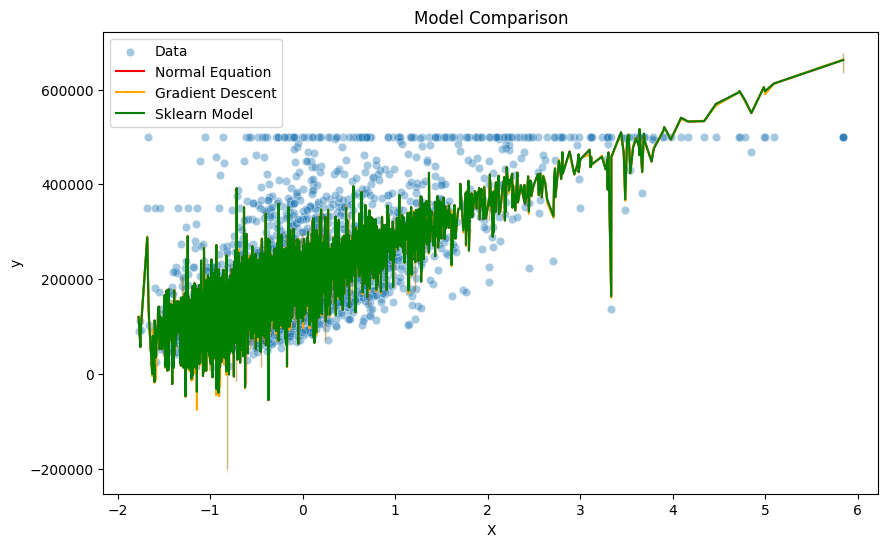

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_val[:, 0].flatten(), y=y_val.flatten(), label="Data", alpha=0.4)
sns.lineplot(x=X_val[:, 0].flatten(), y=y_val_pred_ne.flatten(), color="red",   label="Normal Equation")
sns.lineplot(x=X_val[:, 0].flatten(), y=y_val_pred_gd.flatten(),     color="orange", label="Gradient Descent")
sns.lineplot(x=X_val[:, 0].flatten(), y=y_val_pred_sklearn.flatten(), color="green", label="Sklearn Model")

plt.title("Model Comparison")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

Conclusion

In this task, we built and compared three Linear Regression models to predict 
California house prices.

Key takeaways:

- **Normal Equation and Sklearn** produced identical results, confirming our 
  from-scratch implementation is correct.
- **Gradient Descent** (5000 iterations, lr=0.01) got very close to the exact 
  solution, with only a small gap remaining.
- All models achieved an **RMSE of ~$68,000** and **MAE of ~$50,000**, meaning 
  the average prediction error is around $50,000–$68,000.
- No overfitting was observed validation and test errors were consistent.